# Load Datasets

### Imports y carga de datos

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix


A partir de ahora, solo voy a trabajar con el v_02 y construir a partir de eso.

In [18]:
DATA_PATH = "../data/processed/match_vector_v02.csv"

df = pd.read_csv(DATA_PATH)

df.shape

(128, 135)

In [19]:
df.head()

,match_id,match_date,kick_off,year,home_team,away_team,home_score,away_score,competition_stage,home_Ball Receipt*,...,sum_Interception,sum_Miscontrol,sum_Offside,sum_Own Goal Against,sum_Pass,sum_Player Off,sum_Player On,sum_Pressure,sum_Shield,sum_Shot
0,7525,2018-06-14,15:00:00.000,2018,Russia,Saudi Arabia,5,0,Group Stage,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,7578,2018-06-15,12:00:00.000,2018,Egypt,Uruguay,0,1,Group Stage,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,7577,2018-06-15,15:00:00.000,2018,Morocco,Iran,0,1,Group Stage,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,7576,2018-06-15,18:00:00.000,2018,Portugal,Spain,3,3,Group Stage,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,7530,2018-06-16,10:00:00.000,2018,France,Australia,2,1,Group Stage,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Columns: 135 entries, match_id to sum_Shot
dtypes: float64(125), int64(5), str(5)
memory usage: 135.1 KB


In [21]:
df.isna().sum().sort_values(ascending=False).head(20)

match_id               0
match_date             0
kick_off               0
year                   0
home_team              0
away_team              0
home_score             0
away_score             0
competition_stage      0
home_Ball Receipt*     0
home_Ball Recovery     0
home_Block             0
home_Carry             0
home_Clearance         0
home_Dispossessed      0
home_Dribble           0
home_Dribbled Past     0
home_Duel              0
home_Error             0
home_Foul Committed    0
dtype: int64

In [22]:
df["year"].value_counts().sort_index()

year
2018    64
2022    64
Name: count, dtype: int64

In [23]:
df["target"].value_counts()

target
 1    55
-1    45
 0    28
Name: count, dtype: int64

In [24]:
df["target"].value_counts(normalize=True)

target
 1    0.429688
-1    0.351562
 0    0.218750
Name: proportion, dtype: float64

In [25]:
TARGET = "target"

COLUMNS_TO_DROP = [
    "match_id",
    "match_date",
    "kick_off",
    "year",
    "home_team",
    "away_team",
    "home_score",
    "away_score",
    "competition_stage",
    TARGET,
]

X = df.drop(columns=COLUMNS_TO_DROP)
y = df[TARGET]

print(f"Features: {X.shape[1]}")
print(f"Samples: {X.shape[0]}")

Features: 125
Samples: 128


In [26]:
print(f"Matches: {len(df)}")
print(f"Features: {X.shape[1]}")
print(f"Target classes: {y.nunique()}")

Matches: 128
Features: 125
Target classes: 3


Hay casi 1 feature por muestra. Es pertinente hacer feature selection

In [27]:
y.value_counts()

target
 1    55
-1    45
 0    28
Name: count, dtype: int64

# Baseline Evaluation

## Reutilización de funciones útiles

#### TRAIN - TEST by Year

In [28]:
def split_train_test_by_year(df, target_col="target"):
    train_df = df[df["year"] == 2018].copy()
    test_df = df[df["year"] == 2022].copy()

    columns_to_drop = [
        "match_id",
        "match_date",
        "kick_off",
        "year",
        "home_team",
        "away_team",
        "home_score",
        "away_score",
        "competition_stage",
        target_col
    ]

    X_train = train_df.drop(columns=columns_to_drop)
    y_train = train_df[target_col]

    X_test = test_df.drop(columns=columns_to_drop)
    y_test = test_df[target_col]

    return X_train, X_test, y_train, y_test

    

#### Visor de Resultados

In [37]:
def display_results(results: list, labels=[-1, 0, 1]):
    """
    Displays detailed evaluation metrics for each model result.
    """

    for result in results:

        print("=" * 60)
        print(f"{result['model_name']} - {result['dataset']}")
        print("=" * 60)

        print(f"Accuracy: {result['accuracy']:.3f}")

        print("\nConfusion Matrix:")
        cm_df = pd.DataFrame(
            result["confusion_matrix"],
            index=[f"Real {label}" for label in labels],
            columns=[f"Pred {label}" for label in labels]
        )
        display(cm_df)

        print("\nClassification Report:")
        report_df = pd.DataFrame(result["classification_report"]).T
        display(report_df)

        print("\n")

In [71]:
def summarize_results(results):
    """
    Crea un summary DataFrame de una lista de resultados de evaluación de modelos.
    """

    rows = []

    for result in results:
        rows.append({
            "dataset": result["dataset"],
            "model_name": result["model_name"],
            "accuracy": result["accuracy"]
        })

    summary_df = pd.DataFrame(rows)

    summary_df = summary_df.sort_values(
        by="accuracy",
        ascending=False
    ).reset_index(drop=True)

    return summary_df



#### Evaluación de Modelos

In [29]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name=None, dataset_name=None):
    """
    Entrena y evalúa un modelo de predicción.
    Devuelve dict con resultados.
    """
    
    if model_name is None:                       
        model_name = model.__class__.__name__


    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    cm = confusion_matrix(y_test, predictions)

    report = classification_report(
        y_test,
        predictions,
        output_dict=True,
        zero_division = 0
    )

    return {
        "dataset": dataset_name,
        "model_name": model_name,
        "model": model,
        "predictions": predictions,
        "accuracy": accuracy,
        "confusion_matrix": cm,
        "classification_report": report,
    }



In [72]:
def run_model_comparison(models, datasets, y_train, y_test):
    """
    Corre varios modelos por varios datasets
    Devuelve los resultados y una summary table
    """

    results = []

    for dataset_name, data in datasets.items():

        X_train = data["X_train"]
        X_test = data["X_test"]

        for model_name, model in models.items():

            model_clone = clone(model)

            result = evaluate_model(
                model=model_clone,
                X_train=X_train,
                y_train=y_train,
                X_test=X_test,
                y_test=y_test,
                model_name=model_name,
                dataset_name=dataset_name
            )

            results.append(result)

    summary_df = summarize_results(results)

    return results, summary_df



#### Feature Importance

In [30]:
def get_feature_importance(result, feature_names, top_n=20):
    """
    Creates a feature importance DataFrame for models with feature_importances_.
    """

    model = result["model"]

    if not hasattr(model, "feature_importances_"):
        raise ValueError(
            f"{result['model_name']} does not have feature_importances_."
        )

    if len(model.feature_importances_) != len(feature_names):
        raise ValueError(
            f"Length mismatch: model has {len(model.feature_importances_)} importances "
            f"but {len(feature_names)} feature names were provided."
        )

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        by="importance",
        ascending=False
    ).reset_index(drop=True)

    return importance_df.head(top_n)




## Evaluación de Modelo

In [34]:
X_train, X_test, y_train, y_test = split_train_test_by_year(df)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

baseline_result = evaluate_model(
    model=rf,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    model_name="Random Forest",
    dataset_name="V02 Baseline"
)

display_results([baseline_result])

Random Forest - V02 Baseline
Accuracy: 0.484

Confusion Matrix:


,Pred -1,Pred 0,Pred 1
Real -1,16,1,3
Real 0,10,0,5
Real 1,14,0,15



Classification Report:


,precision,recall,f1-score,support
-1,0.400000,0.800000,0.533333,20.000000
0,0.000000,0.000000,0.000000,15.000000
1,0.652174,0.517241,0.576923,29.000000
accuracy,0.484375,0.484375,0.484375,0.484375
macro avg,0.350725,0.439080,0.370085,64.000000
weighted avg,0.420516,0.484375,0.428085,64.000000


In [38]:
baseline_model = baseline_result["model"]

# Feature Importance Analysis

In [41]:
importance_df = get_feature_importance(
    baseline_result,
    X_train.columns,
    top_n=len(X_train.columns)
)

In [42]:
importance_df.head(20)

,feature,importance
0,diff_Dispossessed,0.021196
1,relative_diff_Dispossessed,0.019666
2,relative_diff_Ball Recovery,0.019130
3,home_Duel,0.018929
4,diff_Clearance,0.018901
5,home_Ball Recovery,0.018761
6,relative_diff_Duel,0.018498
7,sum_Error,0.017572
8,diff_Duel,0.017443
9,relative_diff_Clearance,0.016432


In [43]:
importance_df.tail(20)

,feature,importance
105,diff_Shield,0.003612
106,diff_Bad Behaviour,0.003608
107,away_Bad Behaviour,0.003558
108,away_Shot,0.003482
109,relative_diff_Player On,0.003405
110,relative_diff_Bad Behaviour,0.003390
111,diff_Foul Won,0.003355
112,sum_Dispossessed,0.003325
113,away_Shield,0.003183
114,diff_Offside,0.002815


In [44]:
print(f"Features con importancia = 0: {(importance_df['importance'] == 0).sum()}")

print(f"Features con importancia < 0.001: {(importance_df['importance'] < 0.001).sum()}")

Features con importancia = 0: 0
Features con importancia < 0.001: 3


In [45]:
importance_df[importance_df["importance"] < 0.001]

,feature,importance
122,home_Own Goal Against,0.000741
123,home_Bad Behaviour,0.000508
124,sum_Own Goal Against,0.000500


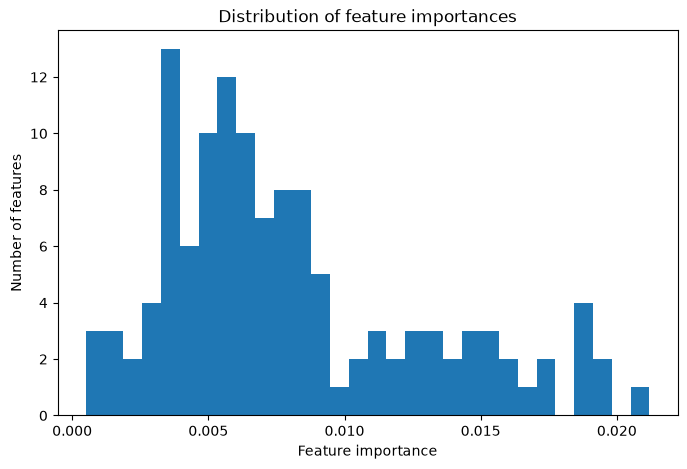

In [46]:
plt.figure(figsize=(8, 5))
plt.hist(importance_df["importance"], bins=30)
plt.xlabel("Feature importance")
plt.ylabel("Number of features")
plt.title("Distribution of feature importances")
plt.show()

In [47]:
importance_df["cumulative_importance"] = importance_df["importance"].cumsum()

importance_df.head(30)

,feature,importance,cumulative_importance
0,diff_Dispossessed,0.021196,0.021196
1,relative_diff_Dispossessed,0.019666,0.040862
2,relative_diff_Ball Recovery,0.019130,0.059992
3,home_Duel,0.018929,0.078921
4,diff_Clearance,0.018901,0.097822
5,home_Ball Recovery,0.018761,0.116583
6,relative_diff_Duel,0.018498,0.135081
7,sum_Error,0.017572,0.152653
8,diff_Duel,0.017443,0.170096
9,relative_diff_Clearance,0.016432,0.186528


In [48]:
importance_df[importance_df["cumulative_importance"] <= 0.80]

,feature,importance,cumulative_importance
0,diff_Dispossessed,0.021196,0.021196
1,relative_diff_Dispossessed,0.019666,0.040862
2,relative_diff_Ball Recovery,0.019130,0.059992
3,home_Duel,0.018929,0.078921
4,diff_Clearance,0.018901,0.097822
...,...,...,...
68,diff_Dribbled Past,0.006337,0.770583
69,home_Block,0.006325,0.776908
70,away_Dribble,0.006159,0.783067
71,relative_diff_Foul Committed,0.006091,0.789158


In [49]:
for threshold in [0.50, 0.70, 0.80, 0.90, 0.95]:
    n_features = (importance_df["cumulative_importance"] <= threshold).sum()
    print(f"{threshold:.0%} cumulative importance: {n_features} features")

50% cumulative importance: 33 features
70% cumulative importance: 58 features
80% cumulative importance: 73 features
90% cumulative importance: 92 features
95% cumulative importance: 104 features


# Correlation Analysis

In [50]:
corr_matrix = X_train.corr()

corr_matrix.shape

(125, 125)

In [51]:
# Mantengo el triángulo superior para evitar la duplicación de pares
upper_corr = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

In [52]:
CORR_THRESHOLD = 0.95

high_corr_pairs = (
    upper_corr
    .stack()
    .reset_index()
)

high_corr_pairs.columns = [
    "feature_a",
    "feature_b",
    "correlation"
]

high_corr_pairs["abs_correlation"] = high_corr_pairs["correlation"].abs()

high_corr_pairs = (
    high_corr_pairs[
        high_corr_pairs["abs_correlation"] >= CORR_THRESHOLD
    ]
    .sort_values("abs_correlation", ascending=False)
    .reset_index(drop=True)
)

high_corr_pairs.head(20)

,feature_a,feature_b,correlation,abs_correlation
0,home_Player Off,home_Player On,1.000000,1.000000
1,away_Player Off,away_Player On,1.000000,1.000000
2,sum_Player Off,sum_Player On,1.000000,1.000000
3,relative_diff_Player Off,relative_diff_Player On,1.000000,1.000000
4,diff_Player Off,diff_Player On,1.000000,1.000000
5,sum_Ball Receipt*,sum_Pass,0.999555,0.999555
6,away_Ball Receipt*,away_Pass,0.998963,0.998963
7,home_Ball Receipt*,home_Pass,0.998854,0.998854
8,sum_Ball Receipt*,sum_Carry,0.996245,0.996245
9,diff_Ball Receipt*,diff_Pass,0.996174,0.996174


In [53]:
importance_lookup = importance_df.set_index("feature")["importance"]

high_corr_pairs["importance_a"] = high_corr_pairs["feature_a"].map(importance_lookup)
high_corr_pairs["importance_b"] = high_corr_pairs["feature_b"].map(importance_lookup)

high_corr_pairs["importance_diff"] = (
    high_corr_pairs["importance_a"] - high_corr_pairs["importance_b"]
).abs()

high_corr_pairs.head(20)

,feature_a,feature_b,correlation,abs_correlation,importance_a,importance_b,importance_diff
0,home_Player Off,home_Player On,1.000000,1.000000,0.003696,0.001914,0.001782
1,away_Player Off,away_Player On,1.000000,1.000000,0.006759,0.005725,0.001034
2,sum_Player Off,sum_Player On,1.000000,1.000000,0.006648,0.005690,0.000959
3,relative_diff_Player Off,relative_diff_Player On,1.000000,1.000000,0.005795,0.003405,0.002390
4,diff_Player Off,diff_Player On,1.000000,1.000000,0.005666,0.003935,0.001731
5,sum_Ball Receipt*,sum_Pass,0.999555,0.999555,0.004744,0.006798,0.002054
6,away_Ball Receipt*,away_Pass,0.998963,0.998963,0.005451,0.004888,0.000563
7,home_Ball Receipt*,home_Pass,0.998854,0.998854,0.013448,0.014125,0.000677
8,sum_Ball Receipt*,sum_Carry,0.996245,0.996245,0.004744,0.012092,0.007349
9,diff_Ball Receipt*,diff_Pass,0.996174,0.996174,0.010838,0.009689,0.001149


In [54]:
print(f"Correlation threshold: {CORR_THRESHOLD}")
print(f"Highly correlated pairs: {len(high_corr_pairs)}")
print(f"Unique features involved: {pd.unique(high_corr_pairs[['feature_a', 'feature_b']].values.ravel()).shape[0]}")

Correlation threshold: 0.95
Highly correlated pairs: 60
Unique features involved: 70


In [55]:
high_corr_pairs["less_important_feature"] = np.where(
    high_corr_pairs["importance_a"] < high_corr_pairs["importance_b"],
    high_corr_pairs["feature_a"],
    high_corr_pairs["feature_b"]
)

high_corr_pairs["more_important_feature"] = np.where(
    high_corr_pairs["importance_a"] >= high_corr_pairs["importance_b"],
    high_corr_pairs["feature_a"],
    high_corr_pairs["feature_b"]
)

high_corr_pairs["less_importance"] = high_corr_pairs[
    ["importance_a", "importance_b"]
].min(axis=1)

high_corr_pairs["more_importance"] = high_corr_pairs[
    ["importance_a", "importance_b"]
].max(axis=1)

high_corr_pairs["importance_ratio"] = (
    high_corr_pairs["less_importance"] / high_corr_pairs["more_importance"]
)

high_corr_pairs.sort_values(
    ["abs_correlation", "importance_ratio"],
    ascending=[False, True]
).head(30)

,feature_a,feature_b,correlation,abs_correlation,importance_a,importance_b,importance_diff,less_important_feature,more_important_feature,less_importance,more_importance,importance_ratio
0,home_Player Off,home_Player On,1.000000,1.000000,0.003696,0.001914,0.001782,home_Player On,home_Player Off,0.001914,0.003696,0.517740
3,relative_diff_Player Off,relative_diff_Player On,1.000000,1.000000,0.005795,0.003405,0.002390,relative_diff_Player On,relative_diff_Player Off,0.003405,0.005795,0.587579
4,diff_Player Off,diff_Player On,1.000000,1.000000,0.005666,0.003935,0.001731,diff_Player On,diff_Player Off,0.003935,0.005666,0.694427
1,away_Player Off,away_Player On,1.000000,1.000000,0.006759,0.005725,0.001034,away_Player On,away_Player Off,0.005725,0.006759,0.847025
2,sum_Player Off,sum_Player On,1.000000,1.000000,0.006648,0.005690,0.000959,sum_Player On,sum_Player Off,0.005690,0.006648,0.855772
5,sum_Ball Receipt*,sum_Pass,0.999555,0.999555,0.004744,0.006798,0.002054,sum_Ball Receipt*,sum_Pass,0.004744,0.006798,0.697806
6,away_Ball Receipt*,away_Pass,0.998963,0.998963,0.005451,0.004888,0.000563,away_Pass,away_Ball Receipt*,0.004888,0.005451,0.896737
7,home_Ball Receipt*,home_Pass,0.998854,0.998854,0.013448,0.014125,0.000677,home_Ball Receipt*,home_Pass,0.013448,0.014125,0.952057
8,sum_Ball Receipt*,sum_Carry,0.996245,0.996245,0.004744,0.012092,0.007349,sum_Ball Receipt*,sum_Carry,0.004744,0.012092,0.392282
9,diff_Ball Receipt*,diff_Pass,0.996174,0.996174,0.010838,0.009689,0.001149,diff_Pass,diff_Ball Receipt*,0.009689,0.010838,0.893994


Conclusión parcial:

Las variables derivadas presentan una alta correlación estructural con las variables originales debido a su construcción matemática. Sin embargo, esa correlación no implica necesariamente redundancia predictiva, ya que el modelo continúa asignándoles una importancia comparable.

# Redundant Feature Removal

Clave: eliminar solo aquellas de alta correlación y baja importancia

### Funciones útiles

Sugerencia de Features a eliminar

In [56]:
def suggest_feature_removal(
    high_corr_pairs,
    min_corr=0.95,
    max_importance_ratio=0.60,
):
    """
    Sugiere características candidatas para su eliminación basándose en la correlación y la importancia de las características.

    Parámetros
    ----------
    high_corr_pairs : pandas.DataFrame
        DataFrame que contiene pares de características altamente correlacionadas y sus importancias.

    min_corr : float, valor predeterminado=0.95
        Correlación absoluta mínima requerida para considerar un par.

    max_importance_ratio : float, valor predeterminado=0.60
        Relación máxima entre la importancia menor y la mayor de las características.
        Valores más bajos hacen que la selección sea más conservadora.

    Retorna
    -------
    pandas.DataFrame
        DataFrame que contiene las características candidatas para su eliminación.
    """

    candidates = high_corr_pairs[
        (high_corr_pairs["abs_correlation"] >= min_corr)
        &
        (high_corr_pairs["importance_ratio"] <= max_importance_ratio)
    ].copy()

    candidates = candidates[
        [
            "less_important_feature",
            "more_important_feature",
            "abs_correlation",
            "less_importance",
            "more_importance",
            "importance_ratio",
        ]
    ]

    candidates = candidates.rename(
        columns={
            "less_important_feature": "remove_feature",
            "more_important_feature": "keep_feature",
            "abs_correlation": "correlation",
            "less_importance": "remove_importance",
            "more_importance": "keep_importance",
        }
    )

    candidates = candidates.sort_values(
        by=["correlation", "importance_ratio"],
        ascending=[False, True]
    ).reset_index(drop=True)

    return candidates



Validación sobre eliminación

In [58]:
def evaluate_individual_feature_removal(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    candidates,
    baseline_accuracy,
):
    """
    Evalúa el efecto de eliminar individualmente cada característica candidata.

    Parámetros
    ----------
    model : estimador de sklearn
        Modelo base que se clonará y reentrenará para cada experimento.

    X_train, X_test : pandas.DataFrame
        Matrices de características de entrenamiento y prueba.

    y_train, y_test : pandas.Series
        Variables objetivo de entrenamiento y prueba.

    candidates : pandas.DataFrame
        DataFrame devuelto por suggest_feature_removal().

    baseline_accuracy : float
        Exactitud obtenida por el modelo de referencia antes de la eliminación de características.

    Retorna
    -------
    pandas.DataFrame
        Resultados de la evaluación para los experimentos de eliminación individual de características.
    """

    results = []

    for feature in candidates["remove_feature"].unique():

        X_train_reduced = X_train.drop(columns=[feature])
        X_test_reduced = X_test.drop(columns=[feature])

        experiment_model = clone(model)

        experiment_model.fit(X_train_reduced, y_train)

        y_pred = experiment_model.predict(X_test_reduced)

        accuracy = accuracy_score(y_test, y_pred)

        results.append(
            {
                "removed_feature": feature,
                "accuracy": accuracy,
                "delta_accuracy": accuracy - baseline_accuracy,
                "n_features": X_train_reduced.shape[1],
            }
        )

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        by=["delta_accuracy", "accuracy"],
        ascending=False
    ).reset_index(drop=True)

    return results_df

Eliminación de Features seguras de eliminar, reentrenamiento el modelo y cálculo de accuracy

In [61]:
def evaluate_feature_set_removal(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    features_to_remove,
    baseline_accuracy,
):
    """
    Evalúa el efecto de eliminar un conjunto de características simultáneamente.

    Parámetros
    ----------
    model : estimador de sklearn
        Modelo base que se clonará y reentrenará.

    X_train, X_test : pandas.DataFrame
        Matrices de características de entrenamiento y prueba.

    y_train, y_test : pandas.Series
        Variables objetivo de entrenamiento y prueba.

    features_to_remove : list
        Lista de características que se eliminarán conjuntamente.

    baseline_accuracy : float
        Exactitud obtenida por el modelo base antes de la eliminación de características.

    Retorna
    -------
    dict
        Resultado de la evaluación para el experimento de eliminación de un conjunto de características.
    """

    X_train_reduced = X_train.drop(columns=features_to_remove)
    X_test_reduced = X_test.drop(columns=features_to_remove)

    experiment_model = clone(model)

    experiment_model.fit(X_train_reduced, y_train)

    y_pred = experiment_model.predict(X_test_reduced)

    accuracy = accuracy_score(y_test, y_pred)

    result = {
        "experiment": "Feature Set Removal",
        "removed_features": features_to_remove,
        "n_removed_features": len(features_to_remove),
        "n_features": X_train_reduced.shape[1],
        "accuracy": accuracy,
        "delta_accuracy": accuracy - baseline_accuracy,
    }

    return result



En caso de que la eliminación grupal no funcione, se evalúa de manera incremental la eliminación de las Features y se identifica cuál/es no era necesario eliminar.

In [67]:
def evaluate_incremental_feature_removal(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    features_to_remove,
    baseline_accuracy,
):
    """
    Evalúa la eliminación acumulativa de características paso a paso.

    En cada paso, se elimina una característica adicional, 
    se reentrena el modelo y se compara el rendimiento con el de referencia.
    """

    results = []

    current_features_to_remove = []

    for feature in features_to_remove:
        current_features_to_remove.append(feature)

        X_train_reduced = X_train.drop(columns=current_features_to_remove)
        X_test_reduced = X_test.drop(columns=current_features_to_remove)

        experiment_model = clone(model)
        experiment_model.fit(X_train_reduced, y_train)

        y_pred = experiment_model.predict(X_test_reduced)
        accuracy = accuracy_score(y_test, y_pred)

        results.append(
            {
                "step": len(current_features_to_remove),
                "removed_feature": feature,
                "removed_features": current_features_to_remove.copy(),
                "n_removed_features": len(current_features_to_remove),
                "n_features": X_train_reduced.shape[1],
                "accuracy": accuracy,
                "delta_accuracy": accuracy - baseline_accuracy,
            }
        )

    return pd.DataFrame(results)



### Aplicación

Obtengo Features candidatas

In [57]:
candidates = suggest_feature_removal(high_corr_pairs)

candidates.head(20)

,remove_feature,keep_feature,correlation,remove_importance,keep_importance,importance_ratio
0,home_Player On,home_Player Off,1.000000,0.001914,0.003696,0.517740
1,relative_diff_Player On,relative_diff_Player Off,1.000000,0.003405,0.005795,0.587579
2,sum_Ball Receipt*,sum_Carry,0.996245,0.004744,0.012092,0.392282
3,sum_Pass,sum_Carry,0.994801,0.006798,0.012092,0.562165
4,diff_Miscontrol,relative_diff_Miscontrol,0.989294,0.003926,0.006721,0.584087
5,diff_Foul Won,relative_diff_Foul Won,0.985183,0.003355,0.008350,0.401768
6,away_Ball Recovery,sum_Ball Recovery,0.978142,0.005402,0.015804,0.341812
7,relative_diff_Ball Receipt*,diff_Carry,0.969016,0.007848,0.013322,0.589116
8,diff_Shield,relative_diff_Shield,0.968471,0.003612,0.006620,0.545705
9,sum_Block,away_Block,0.960794,0.006536,0.014041,0.465498


Evalúo el accuracy de cada una

In [59]:
baseline_accuracy = baseline_result["accuracy"]

removal_results = evaluate_individual_feature_removal(
    model=rf,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    candidates=candidates,
    baseline_accuracy=baseline_accuracy,
)

removal_results

,removed_feature,accuracy,delta_accuracy,n_features
0,relative_diff_Ball Receipt*,0.515625,0.031250,124
1,home_Player On,0.484375,0.000000,124
2,relative_diff_Player On,0.484375,0.000000,124
3,sum_Ball Receipt*,0.484375,0.000000,124
4,away_Ball Recovery,0.484375,0.000000,124
5,sum_Block,0.484375,0.000000,124
6,diff_Miscontrol,0.468750,-0.015625,124
7,diff_Foul Won,0.468750,-0.015625,124
8,diff_Shield,0.468750,-0.015625,124
9,home_Miscontrol,0.468750,-0.015625,124


Me quedo con las seguras para eliminar

In [60]:
safe_to_remove = removal_results[
    removal_results["delta_accuracy"] >= 0
]

safe_to_remove

,removed_feature,accuracy,delta_accuracy,n_features
0,relative_diff_Ball Receipt*,0.515625,0.03125,124
1,home_Player On,0.484375,0.00000,124
2,relative_diff_Player On,0.484375,0.00000,124
3,sum_Ball Receipt*,0.484375,0.00000,124
4,away_Ball Recovery,0.484375,0.00000,124
5,sum_Block,0.484375,0.00000,124


Elimino las features y reentreno el modelo

In [62]:
features_to_remove = safe_to_remove["removed_feature"].tolist()

features_to_remove

['relative_diff_Ball Receipt*',
 'home_Player On',
 'relative_diff_Player On',
 'sum_Ball Receipt*',
 'away_Ball Recovery',
 'sum_Block']

In [65]:
set_removal_result = evaluate_feature_set_removal(
    model=rf,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    features_to_remove=features_to_remove,
    baseline_accuracy=baseline_accuracy,
)

pd.DataFrame([set_removal_result]).drop(columns=["removed_features"])

,experiment,n_removed_features,n_features,accuracy,delta_accuracy
0,Feature Set Removal,6,119,0.421875,-0.0625


La eliminación grupal resultó ineficiente. Calculo cada una de manera incremental

In [68]:
features_to_remove = safe_to_remove["removed_feature"].tolist()

incremental_results = evaluate_incremental_feature_removal(
    model=rf,
    X_train=X_train,
    X_test=X_test,
    y_train=y_train,
    y_test=y_test,
    features_to_remove=features_to_remove,
    baseline_accuracy=baseline_accuracy,
)

incremental_results.drop(columns=["removed_features"])

,step,removed_feature,n_removed_features,n_features,accuracy,delta_accuracy
0,1,relative_diff_Ball Receipt*,1,124,0.515625,0.031250
1,2,home_Player On,2,123,0.484375,0.000000
2,3,relative_diff_Player On,3,122,0.453125,-0.031250
3,4,sum_Ball Receipt*,4,121,0.453125,-0.031250
4,5,away_Ball Recovery,5,120,0.468750,-0.015625
5,6,sum_Block,6,119,0.421875,-0.062500


In [69]:
accepted_steps = incremental_results[
    incremental_results["delta_accuracy"] >= 0
]

In [70]:
best_safe_step = accepted_steps.iloc[-1]

final_features_to_remove = best_safe_step["removed_features"]

final_features_to_remove

['relative_diff_Ball Receipt*', 'home_Player On']

# Retrain Models

In [73]:
# Creación de matrices con features reducidad en V03
X_train_v03 = X_train.drop(columns=final_features_to_remove)
X_test_v03 = X_test.drop(columns=final_features_to_remove)

print(f"V02 features: {X_train.shape[1]}")
print(f"V03 features: {X_train_v03.shape[1]}")
print(f"Removed features: {len(final_features_to_remove)}")

V02 features: 125
V03 features: 123
Removed features: 2


In [74]:
models = {
    "Dummy Classifier": DummyClassifier(
        strategy="most_frequent"
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),
    "Logistic Regression (Scaled)": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=42))
        ]
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
}


In [76]:
datasets_v03 = {
    "match_vector_v03": {
        "X_train": X_train_v03,
        "X_test": X_test_v03,
    }
}

In [77]:
results_v03, summary_v03 = run_model_comparison(
    models=models,
    datasets=datasets_v03,
    y_train=y_train,
    y_test=y_test,
)

summary_v03

c:\Users\Guido\Documents\Gui Archives\Coding\Mundial 2026\world-cup-predictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,dataset,model_name,accuracy
0,match_vector_v03,Random Forest,0.484375
1,match_vector_v03,Dummy Classifier,0.453125
2,match_vector_v03,Logistic Regression,0.343750
3,match_vector_v03,Logistic Regression (Scaled),0.328125


In [78]:
display_results(results_v03)

Dummy Classifier - match_vector_v03
Accuracy: 0.453

Confusion Matrix:


,Pred -1,Pred 0,Pred 1
Real -1,0,0,20
Real 0,0,0,15
Real 1,0,0,29



Classification Report:


,precision,recall,f1-score,support
-1,0.000000,0.000000,0.000000,20.000000
0,0.000000,0.000000,0.000000,15.000000
1,0.453125,1.000000,0.623656,29.000000
accuracy,0.453125,0.453125,0.453125,0.453125
macro avg,0.151042,0.333333,0.207885,64.000000
weighted avg,0.205322,0.453125,0.282594,64.000000




Logistic Regression - match_vector_v03
Accuracy: 0.344

Confusion Matrix:


...

,precision,recall,f1-score,support
-1,0.363636,0.600000,0.452830,20.000000
0,0.181818,0.266667,0.216216,15.000000
1,0.555556,0.172414,0.263158,29.000000
accuracy,0.328125,0.328125,0.328125,0.328125
macro avg,0.367003,0.346360,0.310735,64.000000
weighted avg,0.407986,0.328125,0.311429,64.000000




Random Forest - match_vector_v03
Accuracy: 0.484

Confusion Matrix:


,Pred -1,Pred 0,Pred 1
Real -1,15,1,4
Real 0,11,0,4
Real 1,13,0,16



Classification Report:


,precision,recall,f1-score,support
-1,0.384615,0.750000,0.508475,20.000000
0,0.000000,0.000000,0.000000,15.000000
1,0.666667,0.551724,0.603774,29.000000
accuracy,0.484375,0.484375,0.484375,0.484375
macro avg,0.350427,0.433908,0.370749,64.000000
weighted avg,0.422276,0.484375,0.432483,64.000000


¿Por qué no cambió nada?

In [79]:
X_train_one = X_train.drop(columns=["relative_diff_Ball Receipt*"])
X_test_one = X_test.drop(columns=["relative_diff_Ball Receipt*"])

In [80]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_one, y_train)

accuracy_score(
    y_test,
    rf.predict(X_test_one)
)

0.515625

In [82]:
X_train_one = X_train.drop(columns=["home_Player On"])
X_test_one = X_test.drop(columns=["home_Player On"])

In [84]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_one, y_train)

accuracy_score(
    y_test,
    rf.predict(X_test_one)
)

0.484375

### Oficialización de feature to remove (accuracy 0.484 -> 0.516)

Aunque la validación incremental sugería inicialmente eliminar dos características, una verificación adicional demostró que eliminar únicamente `relative_diff_Ball Receipt*` producía el mejor resultado con Random Forest.

Eliminar solo `home_Player On` no mejoró el rendimiento, y eliminarla junto con `relative_diff_Ball Receipt*` anuló la mejora obtenida al eliminar la primera característica.

Por lo tanto, el conjunto de datos final V03 elimina únicamente `relative_diff_Ball Receipt*`.

In [87]:
final_features_to_remove = [
    "relative_diff_Ball Receipt*"
]

X_train_v03 = X_train.drop(columns=final_features_to_remove)
X_test_v03 = X_test.drop(columns=final_features_to_remove)

In [88]:
print(f"V02 features: {X_train.shape[1]}")
print(f"V03 features: {X_train_v03.shape[1]}")
print(f"Removed features: {final_features_to_remove}")

V02 features: 125
V03 features: 124
Removed features: ['relative_diff_Ball Receipt*']


Entonces

In [90]:
datasets_v03 = {
    "match_vector_v03": {
        "X_train": X_train_v03,
        "X_test": X_test_v03,
    }
}

In [91]:
results_v03, summary_v03 = run_model_comparison(
    models=models,
    datasets=datasets_v03,
    y_train=y_train,
    y_test=y_test,
)

summary_v03

c:\Users\Guido\Documents\Gui Archives\Coding\Mundial 2026\world-cup-predictor\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,dataset,model_name,accuracy
0,match_vector_v03,Random Forest,0.515625
1,match_vector_v03,Dummy Classifier,0.453125
2,match_vector_v03,Logistic Regression,0.343750
3,match_vector_v03,Logistic Regression (Scaled),0.343750


# v02 - v03 Summary

In [92]:
comparison_df = pd.DataFrame({
    "Metric": [
        "Features",
        "Removed Features",
        "Random Forest Accuracy",
        "Dummy Accuracy",
        "Best Model"
    ],
    "V02": [
        X_train.shape[1],
        0,
        0.484375,
        0.453125,
        "Random Forest"
    ],
    "V03": [
        X_train_v03.shape[1],
        len(final_features_to_remove),
        summary_v03.loc[
            summary_v03["model_name"] == "Random Forest",
            "accuracy"
        ].iloc[0],
        summary_v03.loc[
            summary_v03["model_name"] == "Dummy Classifier",
            "accuracy"
        ].iloc[0],
        summary_v03.sort_values(
            "accuracy",
            ascending=False
        ).iloc[0]["model_name"]
    ]
})

comparison_df


,Metric,V02,V03
0,Features,125,124
1,Removed Features,0,1
2,Random Forest Accuracy,0.484375,0.515625
3,Dummy Accuracy,0.453125,0.453125
4,Best Model,Random Forest,Random Forest


### English summary

The feature selection process reduced the dataset from 125 to 124 features.

Although several highly correlated candidates were identified, the experimental validation demonstrated that removing only `relative_diff_Ball Receipt*` consistently improved the Random Forest baseline.

The final V03 dataset achieved an accuracy improvement from **0.484** to **0.516** while preserving the overall dataset structure, confirming that careful feature selection can improve predictive performance without requiring aggressive dimensionality reduction.

### Spanish Summary

El proceso de selección de características redujo el conjunto de datos de 125 a 124 características.

Aunque se identificaron varios candidatos altamente correlacionados, la validación experimental demostró que eliminar únicamente `relative_diff_Ball Receipt*` mejoró consistentemente el modelo base de Bosque Aleatorio.

El conjunto de datos final V03 logró una mejora en la precisión de **0,484** a **0,516**, conservando la estructura general del conjunto de datos, lo que confirma que una selección cuidadosa de características puede mejorar el rendimiento predictivo sin necesidad de una reducción de dimensionalidad agresiva.

# Save match_Vector_03.csv

In [93]:
# Create V03 dataset
match_vector_v03 = df.drop(columns=final_features_to_remove)

print(f"V02 shape: {df.shape}")
print(f"V03 shape: {match_vector_v03.shape}")
print(f"Removed features: {final_features_to_remove}")

V02 shape: (128, 135)
V03 shape: (128, 134)
Removed features: ['relative_diff_Ball Receipt*']


In [94]:
OUTPUT_PATH = "../data/processed/match_vector_v03.csv"

match_vector_v03.to_csv(
    OUTPUT_PATH,
    index=False
)

print(f"Dataset saved to: {OUTPUT_PATH}")

Dataset saved to: ../data/processed/match_vector_v03.csv


In [95]:
saved_df = pd.read_csv(OUTPUT_PATH)

print(f"Saved dataset shape: {saved_df.shape}")
print(f"Feature removed: {'relative_diff_Ball Receipt*' not in saved_df.columns}")

Saved dataset shape: (128, 134)
Feature removed: True


# Discussion & Conclusions

### English

The feature selection process reduced the dataset from 125 to 124 features. Although the initial analysis identified several highly correlated candidates, experimental validation demonstrated that only `relative_diff_Ball Receipt*` consistently improved the Random Forest model performance. This highlights the importance of complementing statistical analysis with retraining experiments before permanently removing features.

### Español

El proceso de selección de variables redujo el dataset de 125 a 124 variables. Aunque el análisis inicial identificó varios candidatos altamente correlacionados, la validación experimental demostró que únicamente `relative_diff_Ball Receipt*` mejoraba consistentemente el rendimiento del modelo Random Forest. Esto evidencia la importancia de complementar el análisis estadístico con experimentos de reentrenamiento antes de eliminar variables de forma definitiva.